In [1]:
import os
import warnings
import logging
import csv

warnings.filterwarnings('ignore')
logging.getLogger().setLevel(logging.ERROR)
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch_xla
import torch_xla.core.xla_model as xm
device = xm.xla_device()
print(f"TPU Device: {device}")
import numpy as np
import pandas as pd
from scipy.special import softmax
from scipy.spatial.distance import mahalanobis
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import MinMaxScaler
from PIL import Image
from torchvision import transforms, models
from torch.utils.data import DataLoader, Dataset
from torchvision.datasets import ImageFolder
from timm import create_model


E0000 00:00:1759614569.340792      10 common_lib.cc:621] Could not set metric server port: INVALID_ARGUMENT: Could not find SliceBuilder port 8471 in any of the 0 ports provided in `tpu_process_addresses`="local"
=== Source Location Trace: === 
learning/45eac/tfrc/runtime/common_lib.cc:232


TPU Device: xla:0


In [2]:
df = pd.read_csv('/kaggle/input/dfvoid/df_highvoid(1).csv')


In [3]:
df['image_path'] = df['image_path'].str.replace(
    '/content/drive/MyDrive/tomato_augmented',
    '/kaggle/input/tomato/tomato_augmented',
    regex=False
)


In [4]:
device = xm.xla_device()
model = models.efficientnet_b0(pretrained=False)
num_classes = 10  
in_features = model.classifier[1].in_features
model.classifier[1] = torch.nn.Linear(in_features, num_classes)

state_dict = torch.load(
    "/kaggle/input/effnet/keras/default/1/tomato_efficientnet_b0_finetuned(3).pth",
    map_location="cpu"
)
model.load_state_dict(state_dict)
model = model.to(device)
model.eval()

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

In [5]:
class ImageDataset(Dataset):
    def __init__(self, image_paths, transform):
        self.image_paths = image_paths
        self.transform = transform
    def __len__(self):
        return len(self.image_paths)
    def __getitem__(self, idx):
        img = Image.open(self.image_paths[idx]).convert("RGB")
        return self.transform(img)

image_paths = df.image_path.to_list()
dataset = ImageDataset(image_paths, transform)

loader = DataLoader(
    dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2,   
    drop_last=False
)


In [6]:
features_list = []
logits_list = []

def hook_fn(module, input, output):
    features_list.append(output.detach().cpu())

layer = model.classifier[1]
handle = layer.register_forward_hook(hook_fn)

with torch.no_grad():
    for batch in loader:
        batch = batch.to(device)
        out = model(batch)
        logits_list.append(out.cpu())

handle.remove()

logits = torch.cat(logits_list).numpy()
features = torch.cat(features_list).numpy()



In [7]:
probs = softmax(logits, axis=1)
confidences = np.max(probs, axis=1)
uncertainty_score = 1 - confidences

k = 5
nn = NearestNeighbors(n_neighbors=k+1, metric='euclidean')
nn.fit(features)
distances, _ = nn.kneighbors(features)
density_score = distances[:, 1:].mean(axis=1)

outlier_score = np.zeros(len(features))
labels = df.normalized_true.values
for cls in np.unique(labels):
    class_mask = (labels == cls)
    Xc = features[class_mask]

    mean_vec = Xc.mean(axis=0)
    cov = np.cov(Xc, rowvar=False) + np.eye(Xc.shape[1]) * 1e-6
    cov_inv = np.linalg.inv(cov)
    diff = Xc - mean_vec
    mahalanobis_dist_sq = np.sum(diff @ cov_inv * diff, axis=1)
    outlier_score[class_mask] = np.sqrt(mahalanobis_dist_sq)


In [8]:
scores = np.vstack([
    uncertainty_score,
    density_score,
    outlier_score
]).T

scaler = MinMaxScaler()
scores_norm = scaler.fit_transform(scores)
uncertainty_norm = scores_norm[:, 0]
density_norm     = scores_norm[:, 1]
outlier_norm     = scores_norm[:, 2]

weights = np.array([1.0, 1.0, 1.0])
void_score = scores_norm @ weights

In [9]:
df["uncertainty_score"] = uncertainty_norm
df["density_score"]     = density_norm
df["outlier_score"]     = outlier_norm

In [10]:
df

,image_path,true_label,predicted_label,confidence,normalized_true,correct,void_score,uncertainty_score,density_score,outlier_score
0,/kaggle/input/tomato/tomato_augmented/Tomato__...,Tomato___Late_blight,Tomato_Leaf_Mold,0.3240,Tomato_Late_blight,False,2.508128,0.823917,0.284303,0.539311
1,/kaggle/input/tomato/tomato_augmented/Tomato__...,Tomato___Late_blight,Tomato_Late_blight,0.7972,Tomato_Late_blight,True,1.980181,0.232053,0.403442,0.384590
2,/kaggle/input/tomato/tomato_augmented/Tomato__...,Tomato___Late_blight,Tomato_Late_blight,0.8382,Tomato_Late_blight,True,1.824364,0.189549,0.259856,0.277208
3,/kaggle/input/tomato/tomato_augmented/Tomato__...,Tomato___Late_blight,Tomato_Early_blight,0.3617,Tomato_Late_blight,False,2.522149,0.786228,0.388819,0.349835
4,/kaggle/input/tomato/tomato_augmented/Tomato__...,Tomato___Late_blight,Tomato_Late_blight,0.9511,Tomato_Late_blight,True,1.850645,0.045977,0.808557,0.711460
...,...,...,...,...,...,...,...,...,...,...
2066,/kaggle/input/tomato/tomato_augmented/Tomato__...,Tomato___Tomato_Yellow_Leaf_Curl_Virus,Tomato_Tomato_yellow_Leaf_Curl_Virus,0.5800,Tomato_Tomato_yellow_Leaf_Curl_Virus,True,2.014040,0.503431,0.119707,0.195363
2067,/kaggle/input/tomato/tomato_augmented/Tomato__...,Tomato___Tomato_Yellow_Leaf_Curl_Virus,Tomato_Tomato_yellow_Leaf_Curl_Virus,0.6894,Tomato_Tomato_yellow_Leaf_Curl_Virus,True,1.901249,0.378277,0.183897,0.150902
2068,/kaggle/input/tomato/tomato_augmented/Tomato__...,Tomato___Tomato_Yellow_Leaf_Curl_Virus,Tomato_Tomato_yellow_Leaf_Curl_Virus,0.6429,Tomato_Tomato_yellow_Leaf_Curl_Virus,True,1.990619,0.433948,0.211149,0.280970
2069,/kaggle/input/tomato/tomato_augmented/Tomato__...,Tomato___Tomato_Yellow_Leaf_Curl_Virus,Tomato_Bacterial_spot,0.7664,Tomato_Tomato_yellow_Leaf_Curl_Virus,False,1.913150,0.276887,0.206649,0.428119


# void_score != uncertainty_score + density_score + outlier_score
Yes, there is a discrepancy here because in theory the void score is expected to equal the sum of its three components, but since we performed this calculation in a separately normalized space, that equality naturally breaks down. This situation is actually quite normal and not a problem to worry about; the truly critical point is identifying which of the three components occupies the largest share in the pool, in other words, which factor contributes the most to raising the void score. What really matters for us is precisely this: whichever component is dominant, we will assign weight accordingly in the targeted augmentation process, thereby highlighting the examples that genuinely indicate epistemic gaps.

In [11]:
score_columns = ['uncertainty_score', 'density_score', 'outlier_score']
df['dominant_component'] = df[score_columns].idxmax(axis=1)
print(df[['void_score', 'dominant_component']].head())
component_distribution = df['dominant_component'].value_counts(normalize=True) * 100
print("\n'df_high_void percantages")
print(component_distribution)

   void_score dominant_component
0    2.508128  uncertainty_score
1    1.980181      density_score
2    1.824364      outlier_score
3    2.522149  uncertainty_score
4    1.850645      density_score

'df_high_void percantages
dominant_component
uncertainty_score    66.055046
outlier_score        26.267504
density_score         7.677451
Name: proportion, dtype: float64


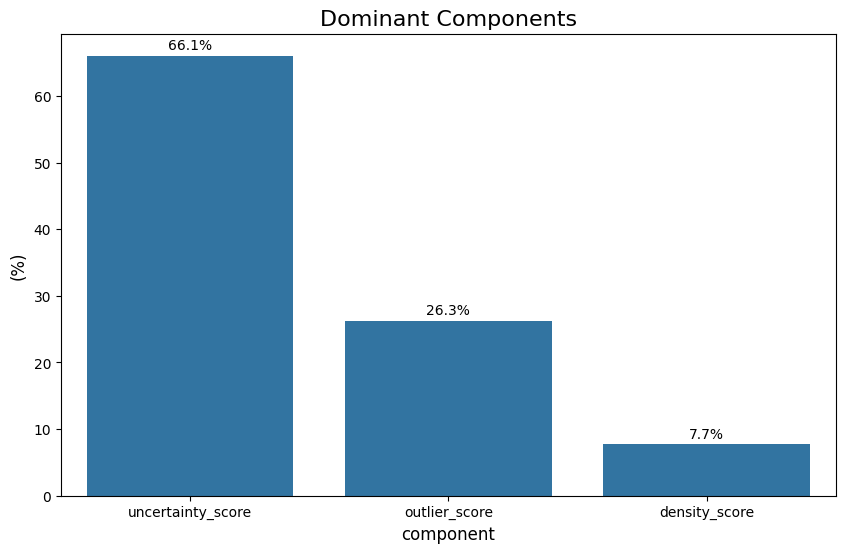

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10, 6))
sns.barplot(x=component_distribution.index, y=component_distribution.values)
plt.title('Dominant Components', fontsize=16)
plt.ylabel('(%)', fontsize=12)
plt.xlabel('component', fontsize=12)
plt.xticks(rotation=0)
for i, v in enumerate(component_distribution.values):
    plt.text(i, v + 0.5, f"{v:.1f}%", ha='center', va='bottom')
plt.show()

# Void Score Analysis: Insights and Strategic Direction
When we applied classic augmentations to a limited (1k) validation set, it predictably introduced “local noise” across the manifold. To measure this noise and other weaknesses, we developed the Void Score — and its component-level breakdown gave us a clear strategic signal.

Among the examples flagged as “problematic,” 66% were primarily driven by low model confidence — a simple and expected metric (1 - confidence).

Since the core goal of this project is to uncover weaknesses beyond basic metrics, we’ll treat that 66% as a general baseline. Our real focus will shift toward the remaining 34% — the critical slice shaped by structural and geometric vulnerabilities in the model (Outlierness + Sparsity). This is where deeper analysis will concentrate, and our generative strategy will be built with special attention to the patterns emerging from this 34%, rather than the more obvious cases.


In [13]:
df_critical_34 = df[
    df['dominant_component'].isin(['outlier_score', 'density_score'])
]
df_uncertain_66 = df[
    df['dominant_component'] == 'uncertainty_score'
]

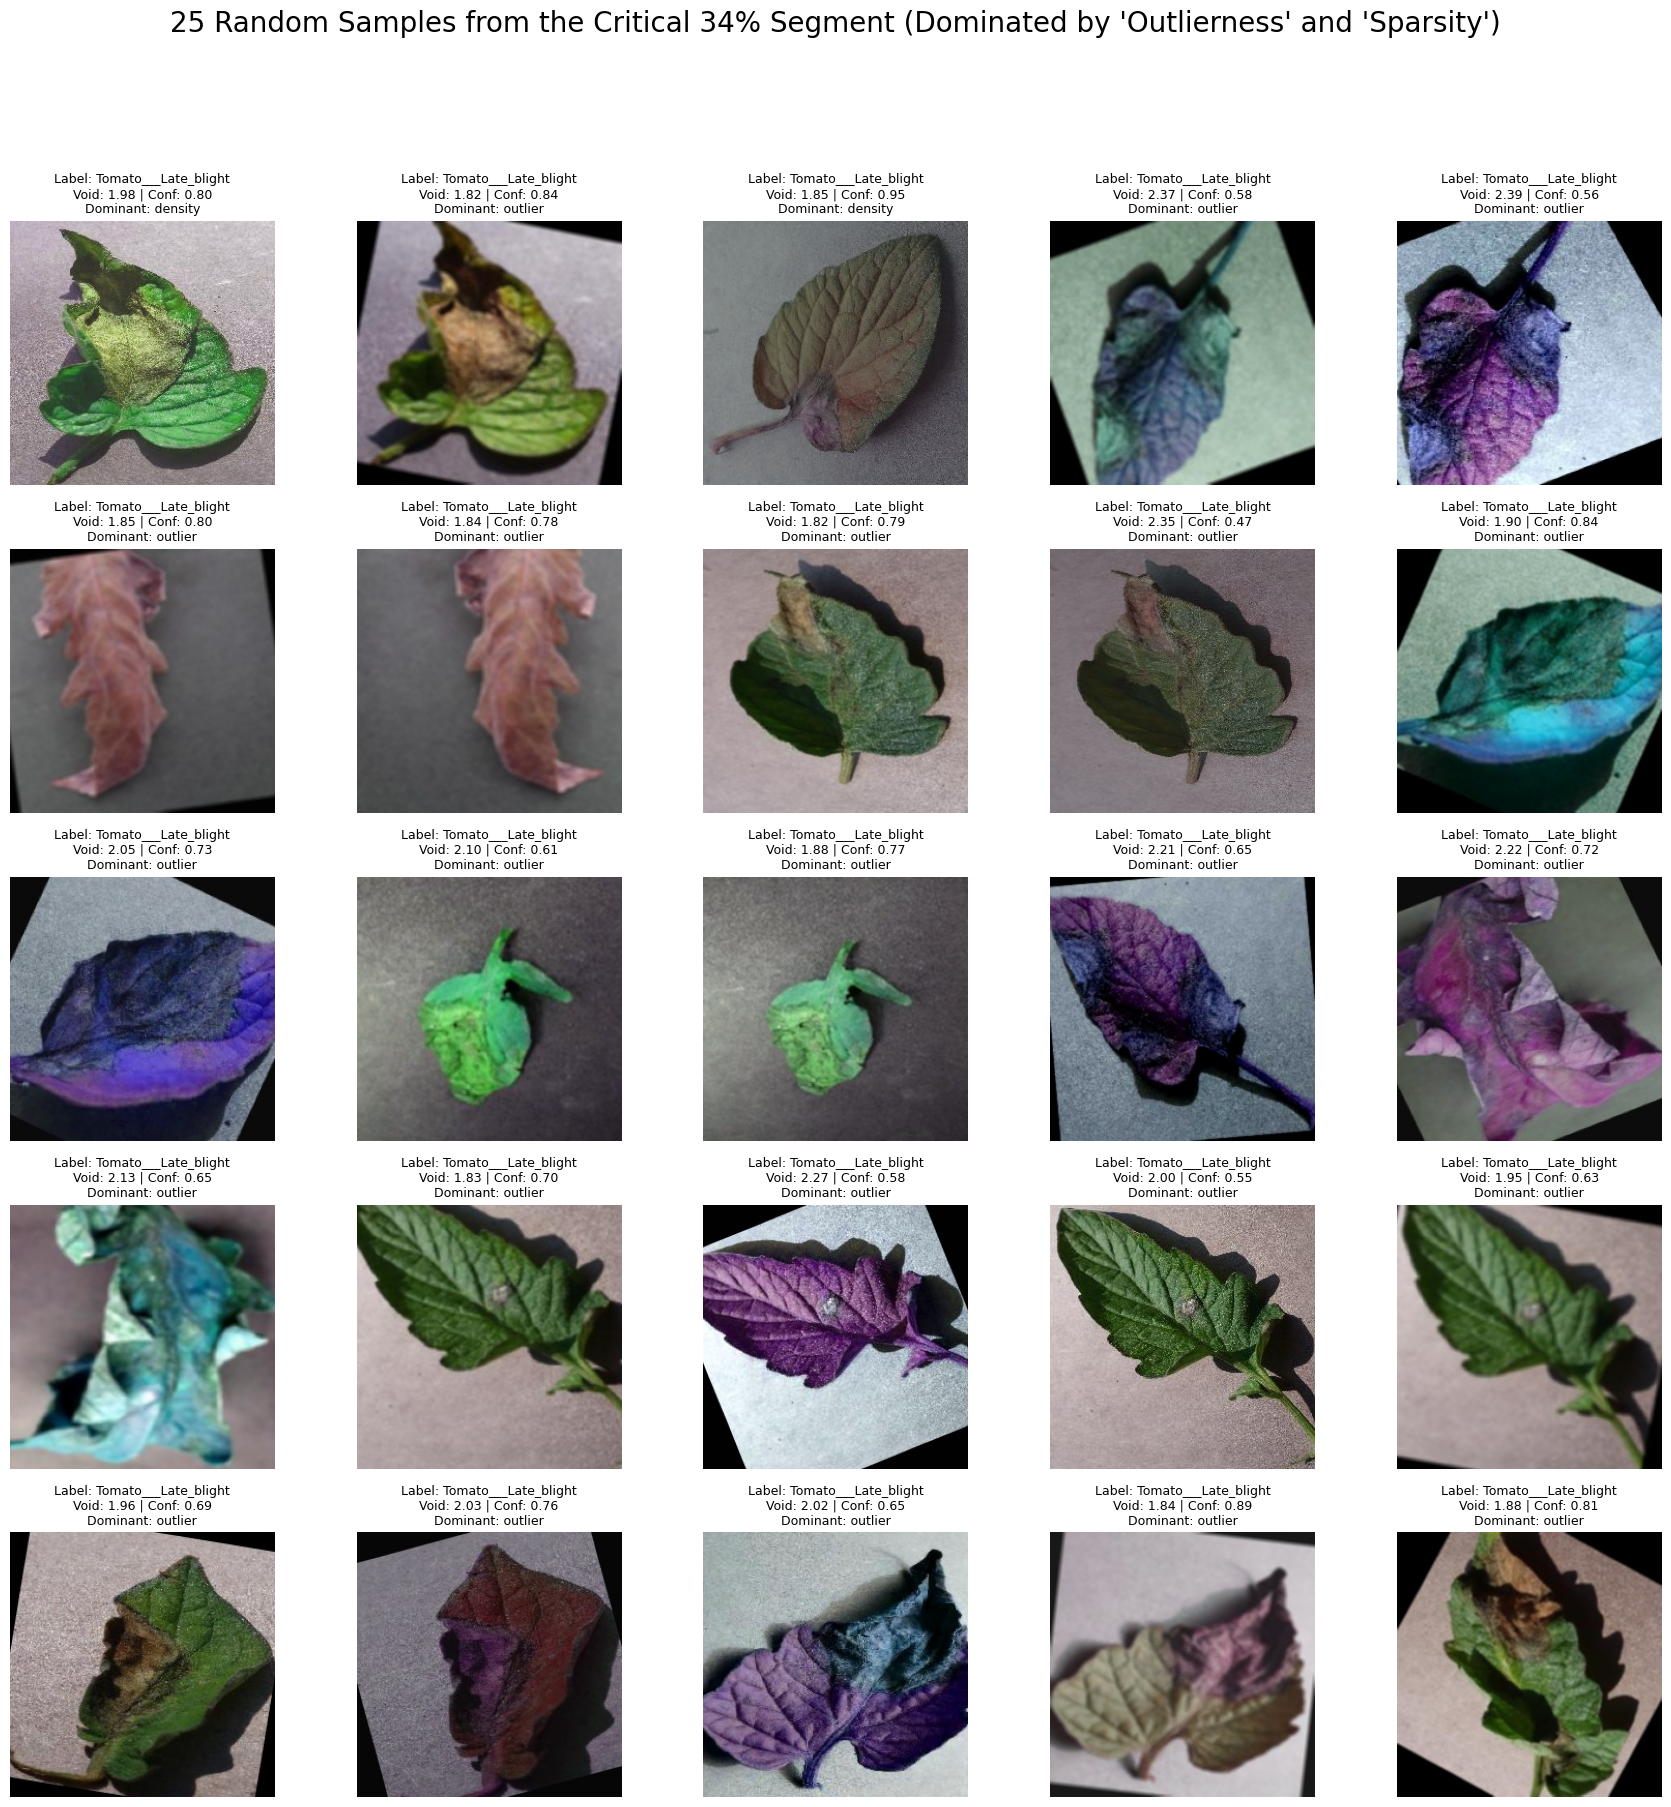

In [14]:
def plot_image_grid(df_subset, title, rows=5, cols=5):
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 3.5, rows * 3.5))
    fig.suptitle(title, fontsize=20, y=1.03)
    axes = axes.flatten()

    for i, (idx, row) in enumerate(df_subset.iterrows()):
        if i >= rows * cols:
            break

        ax = axes[i]
        img = Image.open(row['image_path']).convert('RGB')
        ax.imshow(img)
        dominant_comp = row['dominant_component'].replace('_norm', '').replace('_score', '')
        ax.set_title(
            f"Label: {row['true_label']}\n"
            f"Void: {row['void_score']:.2f} | Conf: {row['confidence']:.2f}\n"
            f"Dominant: {dominant_comp}", 
            fontsize=9
        )
        ax.axis('off')

    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()

num_samples_to_show = 25
plot_image_grid(df_critical_34, "25 Random Samples from the Critical 34% Segment (Dominated by 'Outlierness' and 'Sparsity')")

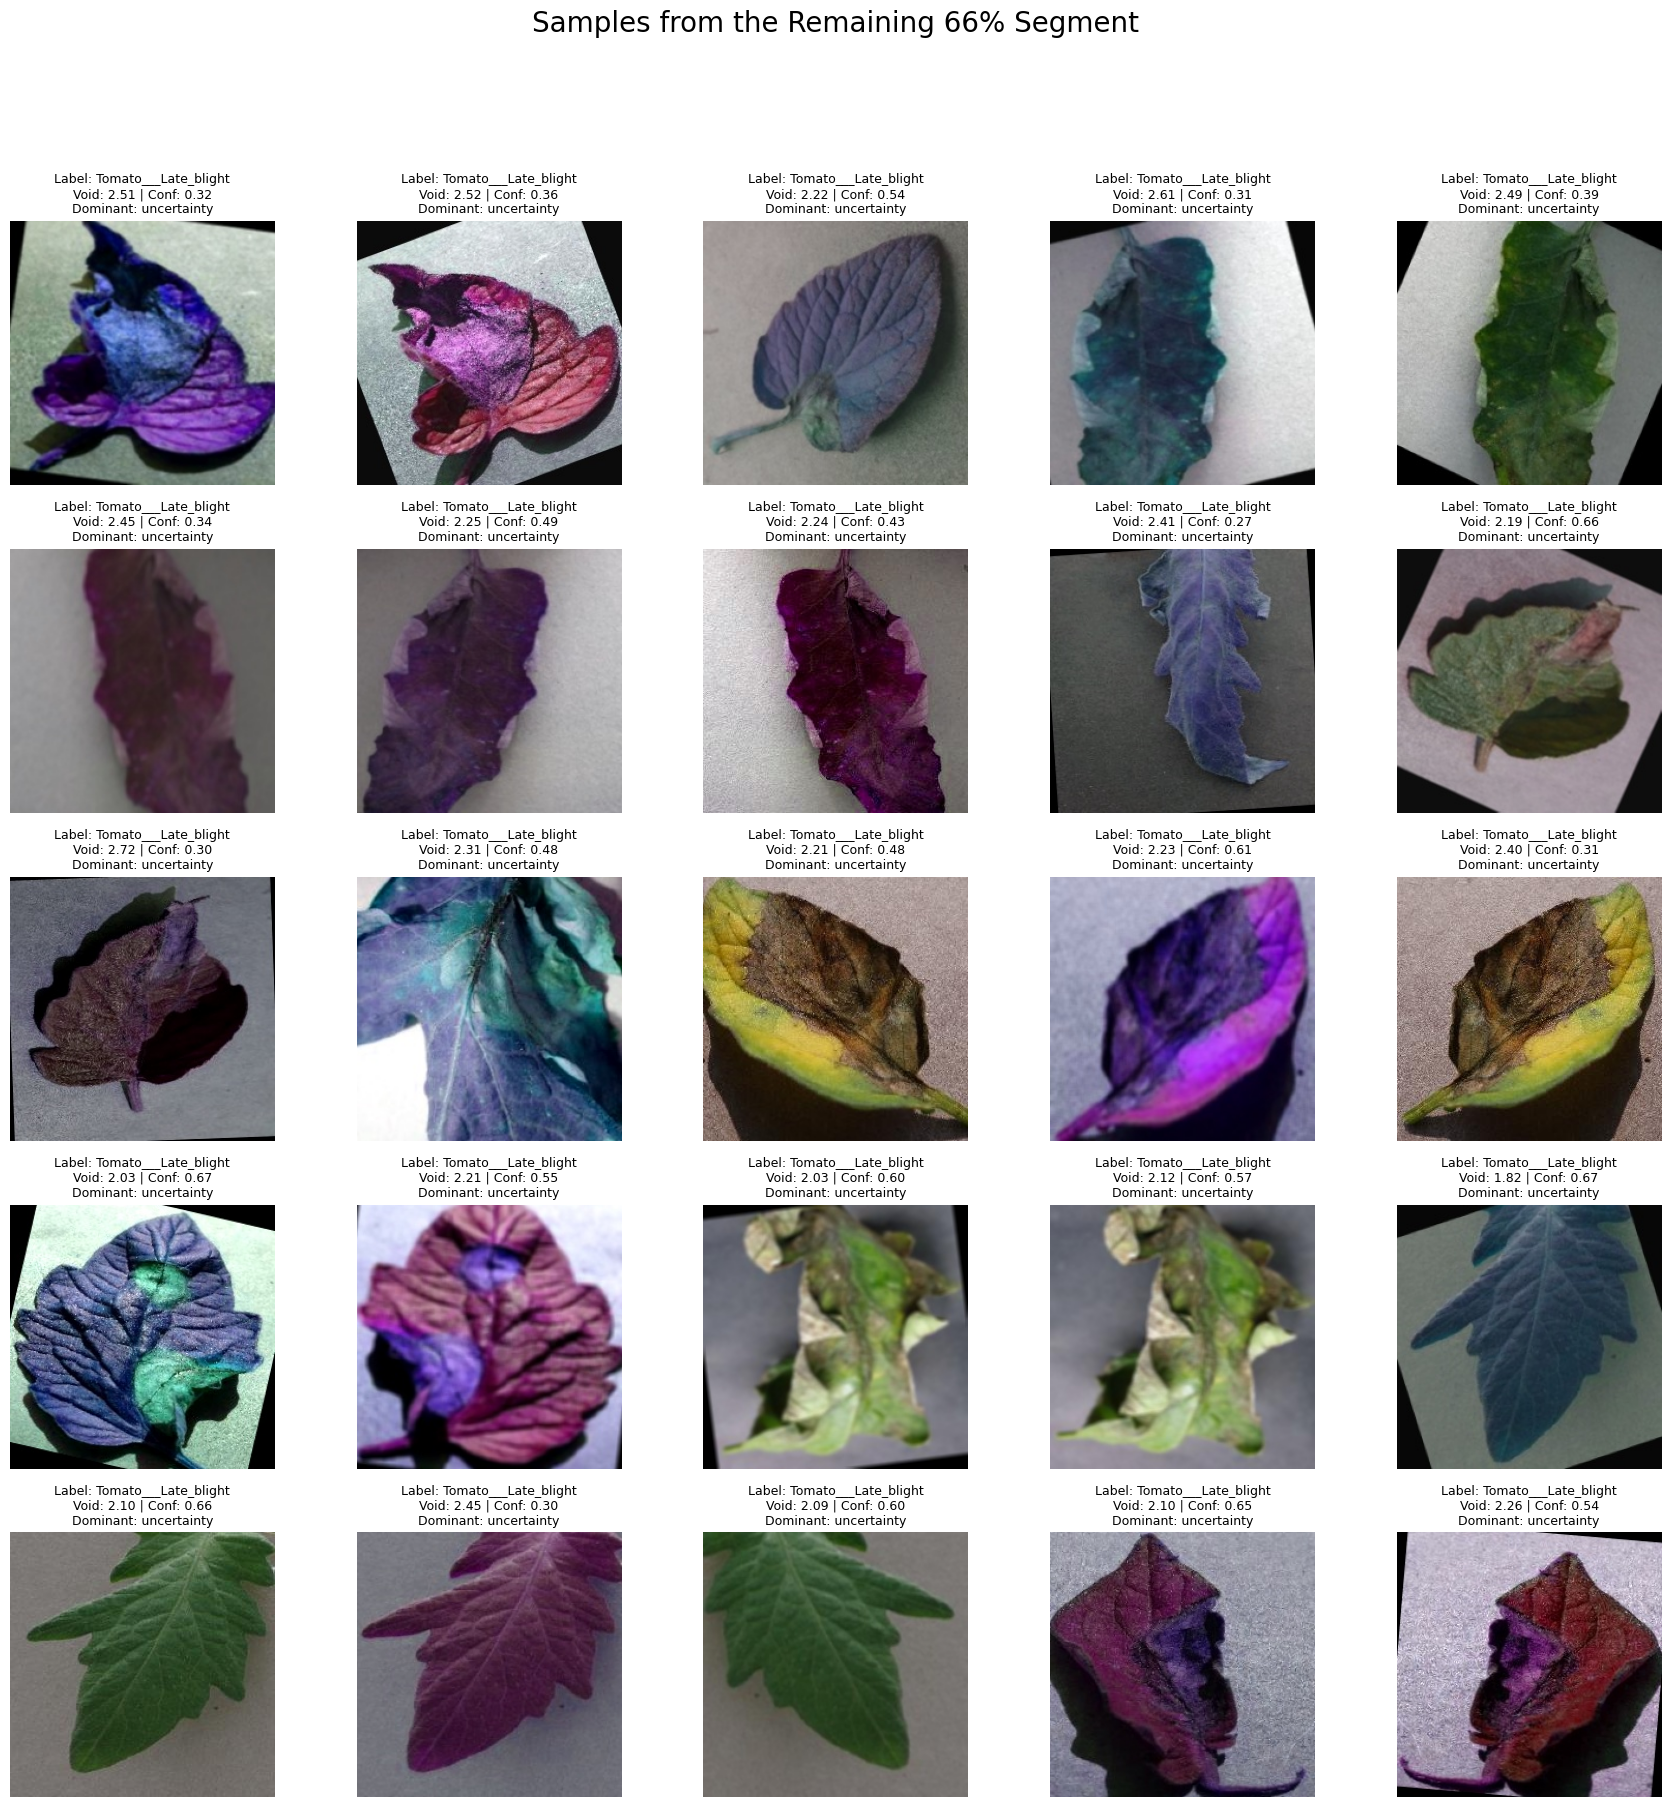

In [15]:
plot_image_grid(df_uncertain_66,"Samples from the Remaining 66% Segment" )